In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
# Convert dates and handle timezones
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
df.head()


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


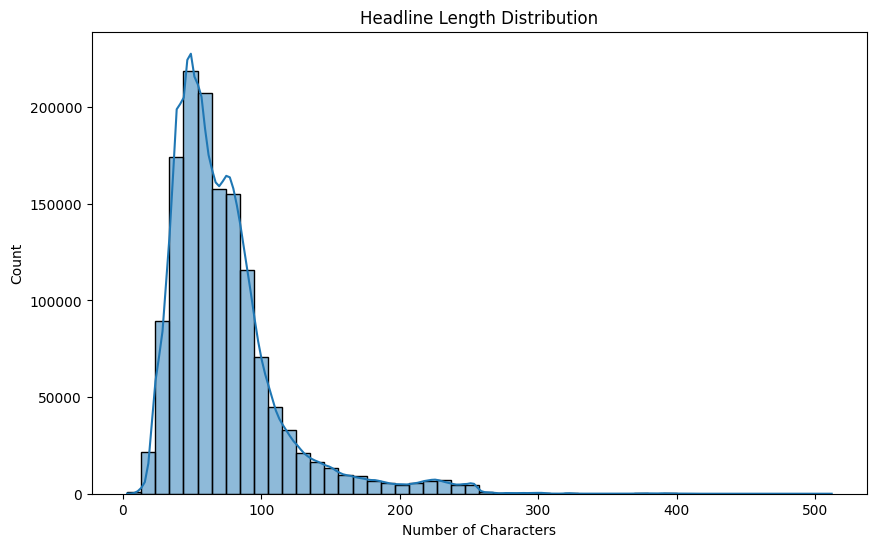

In [8]:
# Calculate character count for each headline
df['headline_len'] = df['headline'].str.len()

# Show statistics
print(df['headline_len'].describe())

# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_len'], bins=50, kde=True)
plt.title('Headline Length Distribution')
plt.xlabel('Number of Characters')
plt.show()


Top 10 Publishers:
 publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

Top Domains:
 domain
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


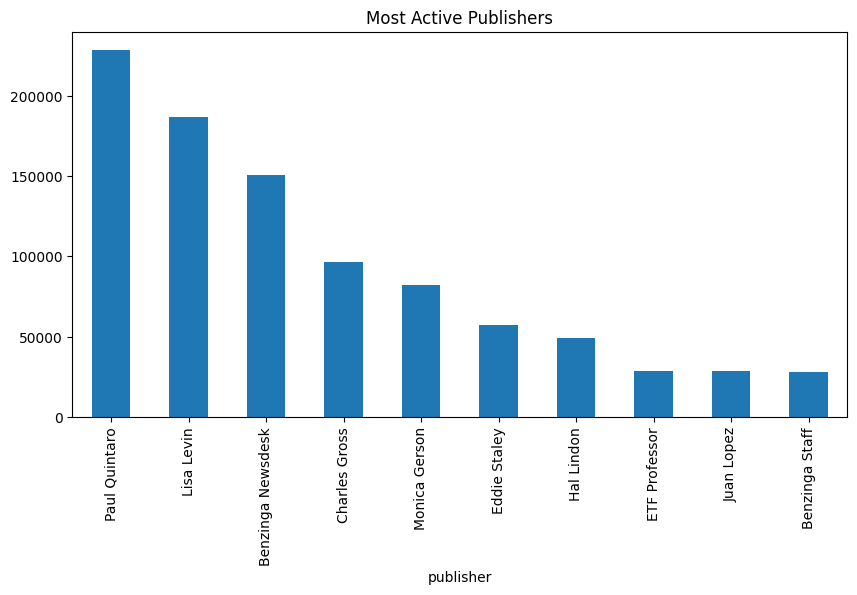

In [9]:
# 1. Count articles per publisher
top_publishers = df['publisher'].value_counts().head(10)
print("Top 10 Publishers:\n", top_publishers)

# 2. Extract domains (Requirement: "extract unique domains")
df['domain'] = df['publisher'].apply(lambda x: x.split('@')[-1] if '@' in str(x) else x)
print("\nTop Domains:\n", df['domain'].value_counts().head(10))

# 3. Plot Top Publishers
top_publishers.plot(kind='bar', figsize=(10, 5), title='Most Active Publishers')
plt.show()


In [14]:
# መጀመሪያ ይህንን Import አድርግ
from sklearn.feature_extraction.text import CountVectorizer

# አሁን የቀረውን ኮድ ማስቀጠል ትችላለህ
cv = CountVectorizer(stop_words='english', max_features=15)
word_count = cv.fit_transform(df['headline'].dropna())
keywords = cv.get_feature_names_out()

print("Top Keywords in Headlines:", keywords)


Top Keywords in Headlines: ['announces' 'benzinga' 'earnings' 'eps' 'est' 'market' 'price' 'pt'
 'reports' 'sales' 'shares' 'stocks' 'update' 'vs' 'week']


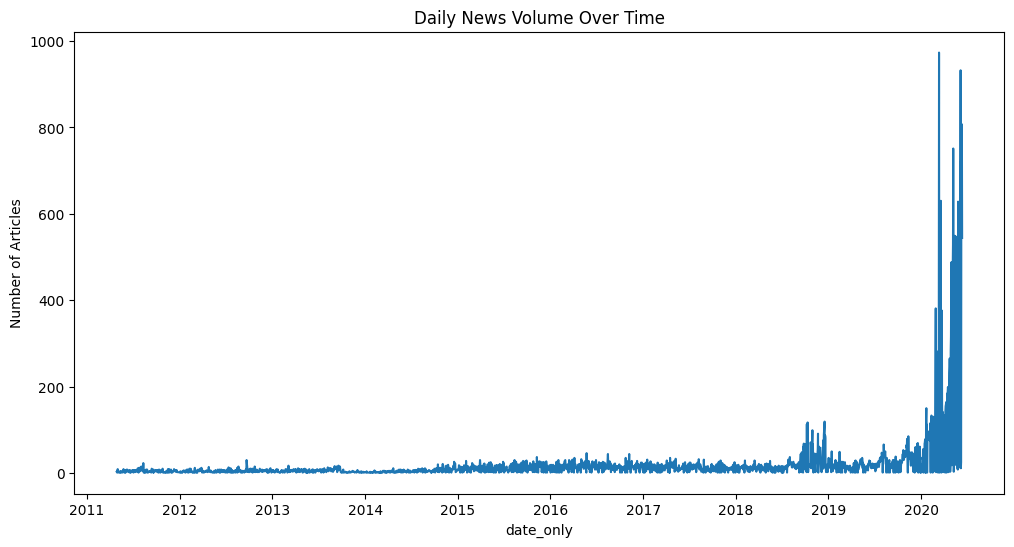

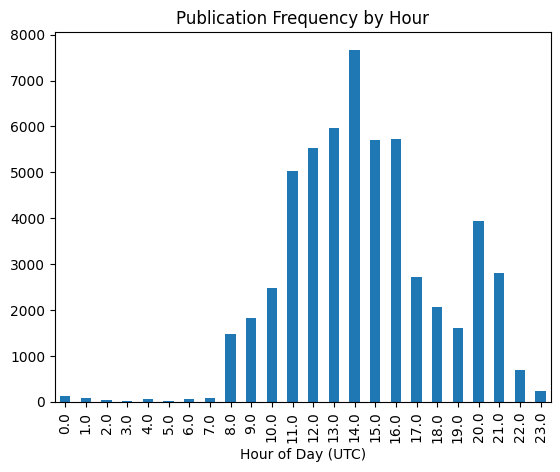

In [15]:
# 1. News volume by day
df['date_only'] = df['date'].dt.date
daily_counts = df['date_only'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
daily_counts.plot(title='Daily News Volume Over Time')
plt.ylabel('Number of Articles')
plt.show()

# 2. News volume by hour (Requirement: "is there a specific time of day?")
df['hour'] = df['date'].dt.hour
df['hour'].value_counts().sort_index().plot(kind='bar', title='Publication Frequency by Hour')
plt.xlabel('Hour of Day (UTC)')
plt.show()
